Code for neural approximations of backgpropagation in Chapter 9 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter9.pdf).

In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# set random seed for reproducibility
np.random.seed(42)

In [27]:
# Data: 100 points of a sine wave
X = np.linspace(-1, 1, 100).reshape(-1, 1)
Y = np.sin(2 * np.pi * X)

In [ ]:
# Neural net architecture: 1 input -> 10 hidden (tanh) -> 1 output (linear)
def train_demo(method='bp', epochs=2000, lr=0.05, sigma=0.01):
    # Initialize weights
    W1 = np.random.randn(1, 10)
    W2 = np.random.randn(10, 1)
    B = np.random.randn(10, 1) # Fixed random matrix for FA
    
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        # Shuffle data for stochastic gradient descent
        idx = np.random.permutation(len(X))
        
        for i in idx:
            x, target = X[i:i+1], Y[i:i+1]
            
            # --- FORWARD PASS ---
            z1 = np.dot(x, W1)
            h = np.tanh(z1)
            y_pred = np.dot(h, W2)
            
            error = y_pred - target
            loss = 0.5 * (error**2)
            epoch_loss += loss.item()
            
            # --- BACKWARD PASS (The different rules) ---
            if method == 'rf':
                # Random feedback: uses fixed B instead of W2.T
                grad_W2 = h.T * error
                grad_h = np.dot(error, B.T) * (1 - h**2)
                grad_W1 = x.T * grad_h
                
                W2 -= lr * grad_W2
                W1 -= lr * grad_W1

            elif method == 'np':
                # Node Perturbation: Jitter the hidden activation
                xi = np.random.randn(1, 10) * sigma
                h_pert = np.tanh(z1 + xi)
                y_pert = np.dot(h_pert, W2)
                loss_pert = 0.5 * (y_pert - target)**2
                
                # Update W2 normally, update W1 by "guessing"
                W2 -= lr * (h.T * error)
                W1 -= (lr / sigma**2) * (loss_pert - loss) * (x.T * xi)

            elif method == 'wp':
                # Weight Perturbation: Jitter the weights
                dW1 = np.random.randn(1, 10) * sigma/10
                dW2 = np.random.randn(10, 1) * sigma/10
                
                y_pert = np.dot(np.tanh(np.dot(x, W1 + dW1)), W2 + dW2)
                loss_pert = 0.5 * (y_pert - target)**2
                
                W1 -= (lr / sigma**2) * (loss_pert - loss) * dW1
                W2 -= (lr / sigma**2) * (loss_pert - loss) * dW2

        if epoch % 100 == 0:
            losses.append(epoch_loss / len(X))
            
    # Return final predictions for plotting
    final_h = np.tanh(np.dot(X, W1))
    return losses, np.dot(final_h, W2)

In [ ]:
# run all methods
methods = ['rf', 'np', 'wp']
results = {m: train_demo(m) for m in methods}

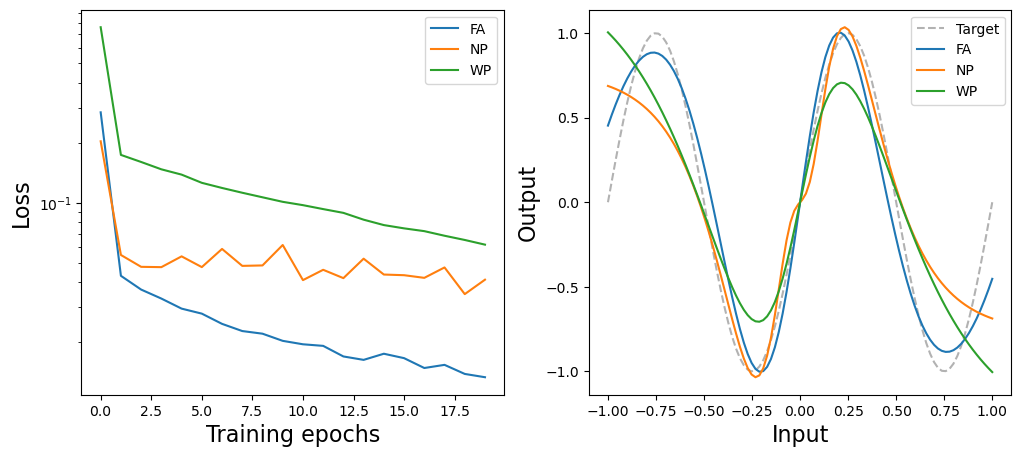

In [33]:
# plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for m in methods:
    plt.plot(results[m][0], label=m.upper())
plt.yscale('log')
plt.ylabel("Loss", fontsize=16)
plt.xlabel("Training epochs", fontsize=16)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X, Y, 'k--', label='Target', alpha=0.3)
for m in methods:
    plt.plot(X, results[m][1], label=m.upper())
plt.ylabel("Output", fontsize=16)
plt.xlabel("Input", fontsize=16)
plt.legend()

plt.savefig("backprop_demo.pdf")